# Part 3 — Smoothing & Exponential Methods

**PyTimeSeries user guide** · *pt.ETS and the mandatory baselines, scored by walk-forward CV.*

> Uses the `pytimeseries` package on the shared commodity-price dataset.

In [1]:
import warnings; warnings.simplefilter("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pytimeseries as pt
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Shared dataset: 356 months of global commodity prices (1992-2021)
raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]); df.index = dates
df.index.name = "date"; df = df.asfreq("MS")
y = df["Food_Price_Index"]
print("pytimeseries", pt.__version__, "| series:", list(df.columns))

pytimeseries 0.5.0 | series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


The package turns forecasting into one line per model. `pt.evaluate` runs a **walk-forward backtest** and **auto-attaches baselines** — you can never score a model in a vacuum.

In [2]:
cv = pt.ExpandingWindow(h=12, n_splits=5)
ets = pt.ETS(trend='add', seasonal='add', seasonal_periods=12)
res = pt.evaluate(ets, y, cv=cv, metrics=('MASE','RMSE'), sp=12)
res.summary

metric,MASE,RMSE
model,,
ETS,0.6858,6.6828
Drift,0.7496,7.3852
Naive,0.7579,7.4806
SeasonalNaive(sp=12),0.9055,8.8899


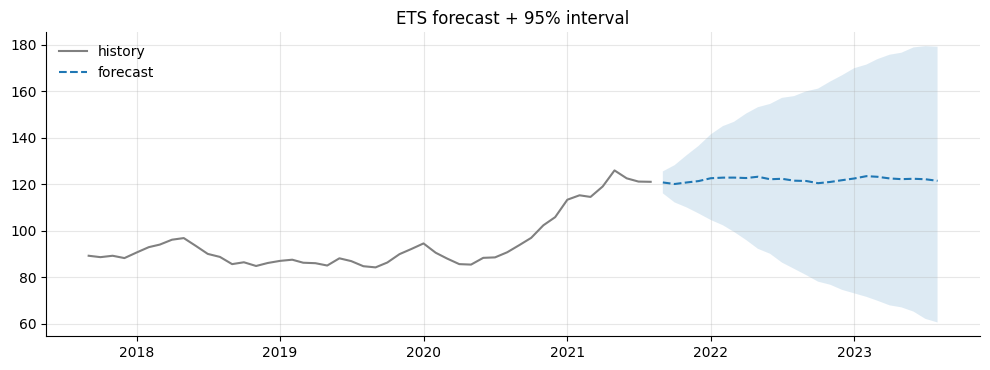

In [3]:
# probabilistic forecast — ETS gives calibrated intervals natively
fit = ets.fit(y)
pi = fit.predict_interval(24, level=[0.8, 0.95])
fig, ax = plt.subplots()
ax.plot(y.index[-48:], y.iloc[-48:], color='0.5', label='history')
ax.plot(pi.index, pi['median'], 'C0--', label='forecast')
ax.fill_between(pi.index, pi['0.95_lower'], pi['0.95_upper'], alpha=.15)
ax.set_title('ETS forecast + 95% interval'); ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Takeaway.** `pt.ETS` + `pt.evaluate` is the whole workflow: fit, backtest against baselines, and read a MASE leaderboard.